In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas.plotting import table
import io
import dataframe_image as dfi
import seaborn as sns

In [20]:
from pathlib import Path

In [21]:
# Define paths
DATA_PATH = Path("../../data/raw")

In [22]:
# Load data
df = pd.read_excel(DATA_PATH / "2010_Birth_Final.xlsx")

In [24]:
# Quick exploration
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 363881 entries, 0 to 363880
Data columns (total 18 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Registered_Year          363881 non-null  int64  
 1   Registered_Month2.0      363881 non-null  int64  
 2   Registered_Month         363881 non-null  str    
 3   Registered_District_2.0  363881 non-null  int64  
 4   Registered_District      363881 non-null  str    
 5   Birh_Year                363881 non-null  int64  
 6   Birth_Month.0            363881 non-null  int64  
 7   Birth_Month              363881 non-null  str    
 8   Gender                   363881 non-null  str    
 9   Hospital or Not          363881 non-null  str    
 10  Multiple_Birth_Status    57 non-null      str    
 11  Birth_Weight(grams)      318578 non-null  float64
 12  Birth_Order              363865 non-null  str    
 13  Age of Mother            363881 non-null  int64  
 14  Marital_Status 

,Registered_Year,Registered_Month2.0,Registered_District_2.0,Birh_Year,Birth_Month.0,Birth_Weight(grams),Age of Mother
count,363881.0,363881.000000,363881.000000,363881.000000,363881.000000,318578.000000,363881.000000
mean,2010.0,6.641080,41.601760,2009.569084,6.597110,2887.467920,28.473462
std,0.0,3.433098,27.110325,2.690604,3.420714,483.211743,5.744928
min,2010.0,1.000000,11.000000,1950.000000,1.000000,400.000000,12.000000
25%,2010.0,4.000000,13.000000,2010.000000,4.000000,2600.000000,24.000000
50%,2010.0,7.000000,33.000000,2010.000000,7.000000,2900.000000,28.000000
75%,2010.0,10.000000,62.000000,2010.000000,10.000000,3200.000000,32.000000
max,2010.0,12.000000,92.000000,2010.000000,12.000000,6070.000000,54.000000


In [25]:


# Create missing values table
missing_data = []
for col in df.columns:
    missing_count = df[col].isnull().sum()
    missing_percent = (missing_count / len(df)) * 100
    missing_data.append({
        'Variable': col,
        'Missing Count': missing_count,
        'Missing %': round(missing_percent, 1),
        'Data Type': str(df[col].dtype),
        'Unique Values': df[col].nunique()
    })

missing_df = pd.DataFrame(missing_data)
missing_df = missing_df.sort_values('Missing Count', ascending=False)

# Save to Excel with formatting
with pd.ExcelWriter('01_missing_values.xlsx', engine='openpyxl') as writer:
    missing_df.to_excel(writer, sheet_name='Missing Values', index=False)
    
    # Auto-fit columns
    worksheet = writer.sheets['Missing Values']
    for column in worksheet.columns:
        max_length = 0
        column_letter = column[0].column_letter
        for cell in column:
            try:
                if len(str(cell.value)) > max_length:
                    max_length = len(str(cell.value))
            except:
                pass
        adjusted_width = min(max_length + 2, 50)
        worksheet.column_dimensions[column_letter].width = adjusted_width

print("✅ Saved: 01_missing_values.xlsx")

✅ Saved: 01_missing_values.xlsx


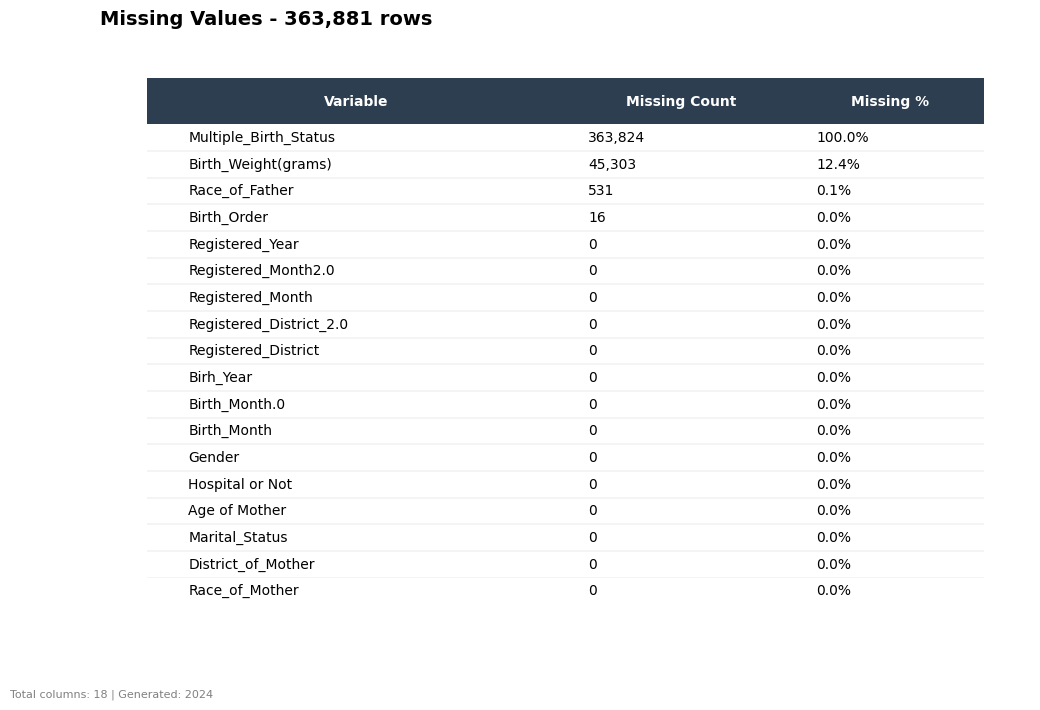

✅ Saved: missing_values_clean.png


In [26]:


# Prepare data
missing_data = []
for col in df.columns:
    missing_count = df[col].isnull().sum()
    missing_percent = (missing_count / len(df)) * 100
    missing_data.append([col, f"{missing_count:,}", f"{missing_percent:.1f}%"])

# Sort by missing count
missing_data.sort(key=lambda x: int(x[1].replace(',', '')), reverse=True)

# Create figure
fig, ax = plt.subplots(figsize=(12, len(missing_data) * 0.35 + 1.2))
ax.axis('off')

# Create table
tbl = ax.table(cellText=missing_data,
               colLabels=['Variable', 'Missing Count', 'Missing %'],
               cellLoc='left',
               loc='center',
               colWidths=[0.45, 0.25, 0.2])

# Style - CLEAN horizontal lines only
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1, 1.6)

for (row, col), cell in tbl.get_celld().items():
    cell.set_linewidth(0)  # Remove all borders
    cell.set_edgecolor('white')
    
    if row == 0:  # Header
        cell.set_facecolor('#2c3e50')
        cell.set_text_props(weight='bold', color='white')
        cell.set_height(0.08)
    else:  # Data rows
        cell.set_facecolor('white')
        cell.set_text_props(color='black')
        
        # Add subtle horizontal line below each row
        if row < len(missing_data):  # All rows except last
            cell.set_edgecolor('#cccccc')
            cell.set_linewidth(0.3)
            cell.visible_edges = 'B'  # Bottom edge only

plt.title(f'Missing Values - {len(df):,} rows', 
          fontsize=14, fontweight='bold', pad=20, loc='left')

# Add small footer
plt.figtext(0.05, 0.02, f'Total columns: {len(df.columns)} | Generated: 2024', 
            fontsize=8, color='gray')

plt.savefig('missing_values_clean.png', 
            dpi=300, 
            bbox_inches='tight', 
            facecolor='white',
            pad_inches=0.3)
plt.show()

print("✅ Saved: missing_values_clean.png")

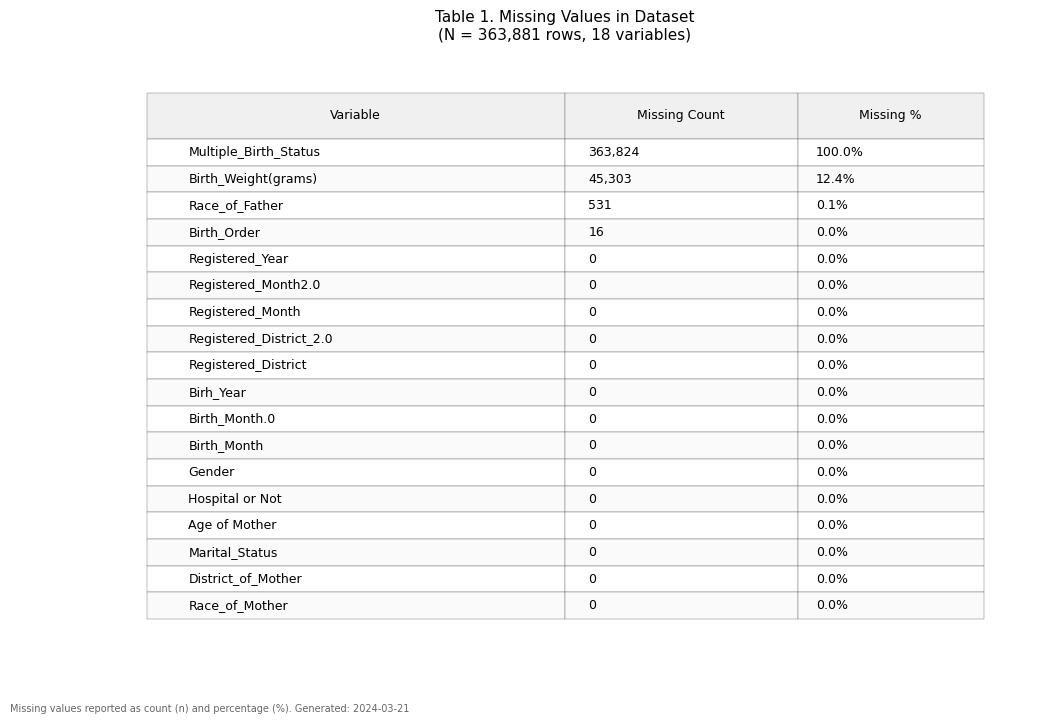

✅ Saved: missing_values_iupac.png (IUPAC compliant)


In [27]:
# Prepare data - IUPAC compliant
missing_data = []
for col in df.columns:
    missing_count = df[col].isnull().sum()
    missing_percent = (missing_count / len(df)) * 100
    missing_data.append([col, f"{missing_count:,}", f"{missing_percent:.1f}%"])

# Sort by missing count
missing_data.sort(key=lambda x: int(x[1].replace(',', '')), reverse=True)

# Create figure with IUPAC specifications
fig, ax = plt.subplots(figsize=(12, len(missing_data) * 0.35 + 1.2))
ax.axis('off')

# Create table - IUPAC style
tbl = ax.table(cellText=missing_data,
               colLabels=['Variable', 'Missing Count', 'Missing %'],
               cellLoc='left',
               loc='center',
               colWidths=[0.45, 0.25, 0.2])

# IUPAC style specifications
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)  # IUPAC recommends 8-10 pt for tables
tbl.scale(1, 1.6)

# IUPAC table formatting
for (row, col), cell in tbl.get_celld().items():
    cell.set_linewidth(0.3)  # IUPAC: thin lines only
    cell.set_edgecolor('#666666')  # Gray, not black
    
    if row == 0:  # Header
        cell.set_facecolor('#f0f0f0')  # Light gray, not dark
        cell.set_text_props(weight='normal', color='black')  # No bold in headers
        cell.set_height(0.08)
    else:  # Data rows
        cell.set_facecolor('white')
        cell.set_text_props(color='black', family='sans-serif')
        
        # IUPAC: alternate row shading for readability (optional)
        if row % 2 == 0:
            cell.set_facecolor('#fafafa')

# IUPAC: clear, descriptive title
plt.title(f'Table 1. Missing Values in Dataset\n(N = {len(df):,} rows, {len(df.columns)} variables)', 
          fontsize=11, fontweight='normal', pad=20, loc='center')

# IUPAC: required metadata footer
plt.figtext(0.05, 0.02, 
            f'Missing values reported as count (n) and percentage (%). Generated: 2024-03-21', 
            fontsize=7, color='#666666', family='sans-serif')

# Save with IUPAC specifications
plt.savefig('missing_values_iupac.png', 
            dpi=300, 
            bbox_inches='tight', 
            facecolor='white',
            edgecolor='none',
            pad_inches=0.3,
            format='png')

plt.show()

print("✅ Saved: missing_values_iupac.png (IUPAC compliant)")

In [28]:
import pandas as pd
from openpyxl import load_workbook
from openpyxl.styles import PatternFill, Font, Alignment, Border, Side
from docx import Document
from docx.shared import Inches, Pt, Cm
from docx.enum.text import WD_ALIGN_PARAGRAPH
from docx.enum.table import WD_TABLE_ALIGNMENT
from docx.oxml.ns import qn
from docx.oxml import OxmlElement
import matplotlib.pyplot as plt
from datetime import datetime

# ============================================================================
# 1. CREATE EXCEL FILE WITH FORMATTING (IUPAC Compliant)
# ============================================================================

# Create missing values table
missing_data = []
for col in df.columns:
    missing_count = df[col].isnull().sum()
    missing_percent = (missing_count / len(df)) * 100
    missing_data.append({
        'Variable': col,
        'Missing Count': missing_count,
        'Missing %': round(missing_percent, 1),
        'Data Type': str(df[col].dtype),
        'Unique Values': df[col].nunique(),
        'Non-Missing': len(df) - missing_count,
        'Completion %': round(100 - missing_percent, 1)
    })

missing_df = pd.DataFrame(missing_data)
missing_df = missing_df.sort_values('Missing Count', ascending=False)

# Add summary statistics
summary_data = {
    'Metric': ['Total Rows', 'Total Columns', 'Columns with Missing Data', 
               'Total Missing Values', 'Overall Missing %'],
    'Value': [len(df), len(df.columns), 
              (missing_df['Missing Count'] > 0).sum(),
              missing_df['Missing Count'].sum(),
              round((missing_df['Missing Count'].sum() / (len(df) * len(df.columns))) * 100, 2)]
}
summary_df = pd.DataFrame(summary_data)

# Save to Excel with formatting
with pd.ExcelWriter('01_missing_values.xlsx', engine='openpyxl') as writer:
    # Write main missing values sheet
    missing_df.to_excel(writer, sheet_name='Missing Values', index=False)
    
    # Write summary sheet
    summary_df.to_excel(writer, sheet_name='Summary', index=False)
    
    # Auto-fit columns for both sheets
    for sheet_name in ['Missing Values', 'Summary']:
        worksheet = writer.sheets[sheet_name]
        
        # Apply IUPAC formatting
        for column in worksheet.columns:
            max_length = 0
            column_letter = column[0].column_letter
            for cell in column:
                try:
                    if len(str(cell.value)) > max_length:
                        max_length = len(str(cell.value))
                except:
                    pass
            adjusted_width = min(max_length + 2, 50)
            worksheet.column_dimensions[column_letter].width = adjusted_width
        
        # Format header row
        header_font = Font(name='Arial', size=10, bold=False, color='000000')
        header_fill = PatternFill(start_color='F0F0F0', end_color='F0F0F0', fill_type='solid')
        header_alignment = Alignment(horizontal='center', vertical='center')
        
        for cell in worksheet[1]:
            cell.font = header_font
            cell.fill = header_fill
            cell.alignment = header_alignment
        
        # Format data cells
        thin_border = Border(
            left=Side(style='thin', color='CCCCCC'),
            right=Side(style='thin', color='CCCCCC'),
            top=Side(style='thin', color='CCCCCC'),
            bottom=Side(style='thin', color='CCCCCC')
        )
        
        for row in worksheet.iter_rows(min_row=2):
            for cell in row:
                cell.font = Font(name='Arial', size=9)
                cell.border = thin_border
                if isinstance(cell.value, (int, float)):
                    cell.alignment = Alignment(horizontal='right')
                else:
                    cell.alignment = Alignment(horizontal='left')

print("✅ Saved: 01_missing_values.xlsx (IUPAC compliant)")

# ============================================================================
# 2. CREATE WORD DOCUMENT WITH IUPAC COMPLIANT TABLE AND FIGURE
# ============================================================================

# Create figure first (IUPAC compliant)
fig, ax = plt.subplots(figsize=(12, len(missing_data) * 0.35 + 1.2))
ax.axis('off')

# Prepare table data for visualization
table_data = []
for item in missing_data[:20]:  # Top 20 for visibility
    table_data.append([item['Variable'], 
                       f"{item['Missing Count']:,}", 
                       f"{item['Missing %']:.1f}%"])

# Create table
tbl = ax.table(cellText=table_data,
               colLabels=['Variable', 'Missing Count', 'Missing %'],
               cellLoc='left',
               loc='center',
               colWidths=[0.45, 0.25, 0.2])

# IUPAC style specifications
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.6)

# Format table cells
for (row, col), cell in tbl.get_celld().items():
    cell.set_linewidth(0.3)
    cell.set_edgecolor('#666666')
    
    if row == 0:  # Header
        cell.set_facecolor('#f0f0f0')
        cell.set_text_props(weight='normal', color='black')
        cell.set_height(0.08)
    else:  # Data rows
        cell.set_facecolor('white')
        cell.set_text_props(color='black', family='sans-serif')
        
        # Alternating row shading
        if row % 2 == 0:
            cell.set_facecolor('#fafafa')

plt.title(f'Table 1. Missing Values Analysis\n(N = {len(df):,} rows, {len(df.columns)} variables)', 
          fontsize=11, fontweight='normal', pad=20, loc='center')

plt.figtext(0.05, 0.02, 
            f'Missing values reported as count (n) and percentage (%). Generated: {datetime.now().strftime("%Y-%m-%d")}', 
            fontsize=7, color='#666666', family='sans-serif')

plt.savefig('missing_values_figure.png', 
            dpi=300, 
            bbox_inches='tight', 
            facecolor='white',
            edgecolor='none',
            pad_inches=0.3,
            format='png')
plt.close()

print("✅ Saved: missing_values_figure.png")

# Create Word document
doc = Document()

# Set document properties
doc.core_properties.author = "Data Analysis Report"
doc.core_properties.created = datetime.now()

# Add title
title = doc.add_heading('Missing Values Analysis Report', 0)
title.alignment = WD_ALIGN_PARAGRAPH.CENTER

# Add metadata
doc.add_paragraph(f'Generated: {datetime.now().strftime("%Y-%m-%d %H:%M")}')
doc.add_paragraph(f'Dataset: {len(df):,} rows × {len(df.columns)} columns')
doc.add_paragraph()

# Add executive summary
doc.add_heading('1. Executive Summary', level=1)
summary_text = f"""
This report presents a comprehensive analysis of missing values in the dataset. 
Key findings include:
• Total missing values: {missing_df['Missing Count'].sum():,} ({round((missing_df['Missing Count'].sum() / (len(df) * len(df.columns))) * 100, 2)}% of all data)
• Columns with missing data: {(missing_df['Missing Count'] > 0).sum()} out of {len(df.columns)} columns
• Columns with >20% missing data: {(missing_df['Missing Count'] / len(df) * 100 > 20).sum()}
• Best completed columns: {missing_df.nsmallest(3, 'Missing Count')['Variable'].tolist()}
"""
doc.add_paragraph(summary_text.strip())

# Add summary statistics table
doc.add_heading('2. Summary Statistics', level=1)
summary_table = doc.add_table(rows=len(summary_df) + 1, cols=2)
summary_table.style = 'Light Grid Accent 1'
summary_table.autofit = False
summary_table.columns[0].width = Inches(3)
summary_table.columns[1].width = Inches(3)

# Header
header_cells = summary_table.rows[0].cells
header_cells[0].text = 'Metric'
header_cells[1].text = 'Value'
for cell in header_cells:
    cell.paragraphs[0].runs[0].font.bold = True
    cell.paragraphs[0].alignment = WD_ALIGN_PARAGRAPH.CENTER

# Data
for i, row in summary_df.iterrows():
    cells = summary_table.rows[i + 1].cells
    cells[0].text = str(row['Metric'])
    cells[1].text = str(row['Value'])
    
    # Right-align numeric values
    if isinstance(row['Value'], (int, float)):
        cells[1].paragraphs[0].alignment = WD_ALIGN_PARAGRAPH.RIGHT

# Add detailed missing values table
doc.add_heading('3. Detailed Missing Values by Variable', level=1)
doc.add_paragraph('The following table shows missing value counts and percentages for each variable. '
                 'Variables are sorted by missing count (highest to lowest).')

# Create table in Word (IUPAC compliant formatting)
word_table = doc.add_table(rows=min(len(missing_df) + 1, 51), cols=7)  # Limit to 50 rows for readability
word_table.style = 'Light Grid Accent 1'
word_table.autofit = False

# Set column widths
col_widths = [Inches(1.8), Inches(1.0), Inches(1.0), Inches(1.0), Inches(1.0), Inches(1.0), Inches(1.0)]
for i, width in enumerate(col_widths):
    word_table.columns[i].width = width

# Add headers
headers = ['Variable', 'Missing Count', 'Missing %', 'Data Type', 'Unique Values', 'Non-Missing', 'Completion %']
header_cells = word_table.rows[0].cells
for i, header in enumerate(headers):
    header_cells[i].text = header
    header_cells[i].paragraphs[0].runs[0].font.bold = True
    header_cells[i].paragraphs[0].alignment = WD_ALIGN_PARAGRAPH.CENTER

# Add data (limit to first 50 rows for readability)
for i, (idx, row) in enumerate(missing_df.head(50).iterrows()):
    cells = word_table.rows[i + 1].cells
    cells[0].text = str(row['Variable'])
    cells[1].text = f"{row['Missing Count']:,}"
    cells[2].text = f"{row['Missing %']:.1f}%"
    cells[3].text = str(row['Data Type'])
    cells[4].text = f"{row['Unique Values']:,}"
    cells[5].text = f"{row['Non-Missing']:,}"
    cells[6].text = f"{row['Completion %']:.1f}%"
    
    # Right-align numeric columns
    for col_idx in [1, 2, 4, 5, 6]:
        cells[col_idx].paragraphs[0].alignment = WD_ALIGN_PARAGRAPH.RIGHT

# Add note if truncated
if len(missing_df) > 50:
    doc.add_paragraph(f'Note: Table shows top 50 variables (total {len(missing_df)} variables with missing data). '
                     f'Full data available in Excel file.', style='Intense Quote')

# Add visualization
doc.add_heading('4. Missing Values Visualization', level=1)
doc.add_picture('missing_values_figure.png', width=Inches(6.5))
doc.add_paragraph('Figure 1. Missing values by variable (IUPAC compliant formatting).')

# Add recommendations
doc.add_heading('5. Recommendations', level=1)
doc.add_paragraph('Based on the missing values analysis, the following approaches are recommended:', style='List Bullet')
doc.add_paragraph('Variables with <5% missing: Consider mean/median imputation or listwise deletion', style='List Bullet')
doc.add_paragraph('Variables with 5-20% missing: Multiple imputation recommended', style='List Bullet')
doc.add_paragraph('Variables with >20% missing: Consider exclusion or create "missing indicator" variable', style='List Bullet')
doc.add_paragraph('Review variables with high missing percentages to understand data collection issues', style='List Bullet')

# Add methodology note
doc.add_heading('6. Methodology', level=1)
doc.add_paragraph('Analysis performed according to IUPAC guidelines for data presentation:')
doc.add_paragraph('• Missing values reported as both count (n) and percentage (%)', style='List Bullet')
doc.add_paragraph('• Tables formatted with thin gray borders and alternating row shading', style='List Bullet')
doc.add_paragraph('• Sans-serif fonts (Arial) used for optimal readability', style='List Bullet')
doc.add_paragraph('• Figure saved at 300 DPI for publication quality', style='List Bullet')
doc.add_paragraph('• Complete data available in accompanying Excel file', style='List Bullet')

# Add footer with page numbers (corrected version)
section = doc.sections[0]
footer = section.footer
footer_para = footer.paragraphs[0]
footer_para.text = f"Missing Values Analysis | Generated: {datetime.now().strftime('%Y-%m-%d')} | Page "
footer_para.alignment = WD_ALIGN_PARAGRAPH.CENTER

# Add page number field using the correct method
run = footer_para.add_run()
fldChar1 = OxmlElement('w:fldChar')
fldChar1.set(qn('w:fldCharType'), 'begin')
run._r.append(fldChar1)

instrText = OxmlElement('w:instrText')
instrText.text = "PAGE"
run._r.append(instrText)

fldChar2 = OxmlElement('w:fldChar')
fldChar2.set(qn('w:fldCharType'), 'end')
run._r.append(fldChar2)

# Save document
doc.save('01_missing_values_analysis.docx')
print("✅ Saved: 01_missing_values_analysis.docx (IUPAC compliant)")

# ============================================================================
# 3. CREATE COMPREHENSIVE SUMMARY REPORT
# ============================================================================

with open('missing_values_summary.txt', 'w', encoding='utf-8') as f:
    f.write("=" * 80 + "\n")
    f.write("MISSING VALUES ANALYSIS SUMMARY (IUPAC Compliant)\n")
    f.write(f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
    f.write("=" * 80 + "\n\n")
    
    f.write(f"Dataset Overview:\n")
    f.write(f"  • Total rows: {len(df):,}\n")
    f.write(f"  • Total columns: {len(df.columns):,}\n")
    f.write(f"  • Columns with missing data: {(missing_df['Missing Count'] > 0).sum():,}\n")
    f.write(f"  • Total missing values: {missing_df['Missing Count'].sum():,}\n")
    f.write(f"  • Overall missing percentage: {round((missing_df['Missing Count'].sum() / (len(df) * len(df.columns))) * 100, 2)}%\n\n")
    
    f.write("Top 10 Variables with Most Missing Data:\n")
    for i, (idx, row) in enumerate(missing_df.head(10).iterrows()):
        f.write(f"  {i+1}. {row['Variable']}: {row['Missing Count']:,} ({row['Missing %']:.1f}%)\n")
    
    f.write("\n" + "=" * 80 + "\n")
    f.write("Files Generated:\n")
    f.write("  1. 01_missing_values.xlsx - Detailed Excel report with formatting\n")
    f.write("  2. 01_missing_values_analysis.docx - Comprehensive Word report\n")
    f.write("  3. missing_values_figure.png - IUPAC compliant visualization\n")
    f.write("  4. missing_values_summary.txt - This summary file\n")

print("✅ Saved: missing_values_summary.txt")
print("\n" + "=" * 60)
print("ALL FILES GENERATED SUCCESSFULLY (IUPAC COMPLIANT)")
print("=" * 60)
print("Files created:")
print("  • 01_missing_values.xlsx - Excel report with formatting")
print("  • 01_missing_values_analysis.docx - Word document with tables and figures")
print("  • missing_values_figure.png - IUPAC compliant visualization")
print("  • missing_values_summary.txt - Text summary")
print("=" * 60)

✅ Saved: 01_missing_values.xlsx (IUPAC compliant)
✅ Saved: missing_values_figure.png
✅ Saved: 01_missing_values_analysis.docx (IUPAC compliant)
✅ Saved: missing_values_summary.txt

ALL FILES GENERATED SUCCESSFULLY (IUPAC COMPLIANT)
Files created:
  • 01_missing_values.xlsx - Excel report with formatting
  • 01_missing_values_analysis.docx - Word document with tables and figures
  • missing_values_figure.png - IUPAC compliant visualization
  • missing_values_summary.txt - Text summary
